
# ⏱️Motivación práctica: ¿Por qué medir el tiempo de ejecución?

Ya conoces cómo analizar la **complejidad temporal** de un algoritmo usando notación Big-O. Eso nos da una idea general de **cómo crece el tiempo de ejecución** a medida que la entrada crece, especialmente para entradas muy grandes.

Pero… ¿qué pasa si tenemos dos algoritmos con la **misma complejidad** y aún así **uno es mucho más rápido** que el otro en la práctica?

Veamos un caso real. Observa estas dos funciones:

```python
# Función 1: usa sum() directamente
def suma_rapida(lista):
    return sum(lista)

# Función 2: usa un ciclo manual para sumar
def suma_lenta(lista):
    total = 0
    for elemento in lista:
        total += elemento
    return total
```

Ambas funciones tienen **complejidad O(n)**, porque recorren una lista de tamaño `n`. Sin embargo, al medir su desempeño real, una es más rápida que la otra.

---

## 🔍 ¿Por qué se da esta diferencia?

La función `sum()` está **altamente optimizada internamente** por Python (usa C internamente, sin pasar por la capa de Python puro). En cambio, un ciclo `for` manual ejecuta muchas más instrucciones a nivel de Python, lo cual es más lento.

➡️ Esto nos muestra algo muy importante:

> **El análisis asintótico no siempre es suficiente para tomar decisiones sobre cuál implementación usar.**

---

## 🧠 ¿Qué tipo de intuiciones queremos desarrollar?

* Que dos algoritmos con la misma notación Big-O **pueden tener rendimientos muy distintos en la práctica**.
* Que una función simple puede esconder una gran cantidad de **procesamiento optimizado**.
* Que al medir, no siempre se trata solo del tamaño de la entrada, sino también de **cómo está escrita** la función y **cómo se comporta en tu entorno real**.

---

## 🧪 Ejercicio de reflexión

### Código de prueba

```python
import time

lista = list(range(1_000_000))

# Medimos suma_rapida
inicio = time.time()
suma_rapida(lista)
fin = time.time()
print("Tiempo suma_rapida:", fin - inicio)

# Medimos suma_lenta
inicio = time.time()
suma_lenta(lista)
fin = time.time()
print("Tiempo suma_lenta:", fin - inicio)
```

### Preguntas para ti:

* ¿Qué diferencias encuentras en los tiempos?
* ¿Cuál crees que escalaría mejor para una lista de 10 millones de elementos?
* ¿Qué tan confiable crees que es esta medición? ¿Qué podría afectarla?

---

## 📌 Conclusión

En esta sección viste que el rendimiento real **no siempre coincide** con lo que predice el análisis teórico. La única forma de saber con certeza cómo se comporta un algoritmo en tu máquina es **medirlo**.

Y para eso, vamos a introducir una herramienta muy útil: **`timeit`**.

---

In [5]:
import time

# Función 1: usa sum() directamente
def suma_rapida(lista):
    return sum(lista)

# Función 2: usa un ciclo manual para sumar
def suma_lenta(lista):
    total = 0
    for elemento in lista:
        total += elemento
    return total

lista = list(range(1_000_000))

# Medimos suma_rapida
inicio = time.time()
suma_rapida(lista)
fin = time.time()
print("Tiempo suma_rapida:", fin - inicio)

# Medimos suma_lenta
inicio = time.time()
suma_lenta(lista)
fin = time.time()
print("Tiempo suma_lenta:", fin - inicio)

Tiempo suma_rapida: 0.009142398834228516
Tiempo suma_lenta: 0.03662753105163574


# Medición precisa de tiempo con `timeit`

Ahora que sabes por qué es importante **medir el rendimiento real de tu código**, vamos a usar una herramienta poderosa, confiable y sencilla de usar: **el módulo `timeit`**.

## 🎯 ¿Por qué usar `timeit` en lugar de `time.time()`?

Aunque puedes medir tiempos con `time.time()`, como hicimos antes, esa medida:

* Es poco precisa para tiempos muy cortos.
* Se ve afectada por procesos del sistema (como antivirus, otras apps, etc.).
* Solo te da un número. No repite ni promedia.

➡️ **`timeit` soluciona eso.** Ejecuta el código muchas veces, **toma múltiples medidas y entrega resultados promedios**, lo que da una imagen mucho más confiable.

---

## 🛠️ Cómo usar `timeit` desde código

### ✅ Opción 1: Usando `timeit.timeit()`

```python
import timeit

tiempo = timeit.timeit(stmt="sum([i for i in range(100)])", number=10000)
print("Tiempo total en 10000 ejecuciones:", tiempo)
```

📌 Explicación:

* `stmt`: el código a ejecutar, como string.
* `number`: cuántas veces repetir la ejecución.
* El tiempo que se devuelve es el **total de todas las repeticiones**, en segundos.

---

### 🧪 Experimento guiado

Vamos a comparar dos formas de crear una lista:

```python
codigo1 = "[x for x in range(1000)]"
codigo2 = "list(range(1000))"

print("List comprehension:", timeit.timeit(codigo1, number=10000))
print("Función list():", timeit.timeit(codigo2, number=10000))
```

### 🔍 Pregunta para ti:

* ¿Cuál es más rápida? ¿Te lo esperabas?
* ¿Crees que seguiría siendo igual de rápida si la lista fuera mucho más grande?

---

## 🧠 ¿Qué pasa si quiero medir una función que ya tengo definida?

Necesitas importar la función dentro del entorno de `timeit`. Puedes hacerlo con el parámetro `setup`.

### ✅ Ejemplo:

```python
def cuadrado(n):
    return n * n

import timeit
tiempo = timeit.timeit("cuadrado(5)", setup="from __main__ import cuadrado", number=1000000)
print("Tiempo total:", tiempo)
```

🔎 *El parámetro `setup` permite importar variables o funciones antes de ejecutar el código.*

---

## 🔁 Opción avanzada: usar `repeat()`

Si quieres medir varias veces y obtener un rango de resultados:

```python
from timeit import repeat

resultados = repeat("cuadrado(5)", setup="from __main__ import cuadrado", number=1000000, repeat=5)
print(resultados)
```

Esto te da **una lista de tiempos**: uno por cada repetición completa del experimento. Así puedes calcular promedio, desviación, etc.

---

## 📌 Recomendaciones al medir

* Siempre repite varias veces (por eso usamos `number` alto o `repeat`).
* Prueba entradas pequeñas y grandes para ver cómo escala.
* No midas cosas como `print()`, pues su tiempo depende del sistema y no del algoritmo.
* Mide código **puro**, sin interferencias de entrada/salida.

---

## ✅ En resumen

| Comando              | ¿Para qué sirve?                                                   |
| -------------------- | ------------------------------------------------------------------ |
| `timeit.timeit(...)` | Mide el tiempo total de ejecutar un código muchas veces            |
| `timeit.repeat(...)` | Mide varias veces ese tiempo total para comparar entre ejecuciones |
| `setup=...`          | Permite importar funciones o variables a medir                     |
| `number=...`         | Define cuántas veces se ejecutará el código                        |

---


In [12]:
import timeit

tiempo = timeit.timeit(stmt="sum([i for i in range(100)])", number=10000)
print("Tiempo total en 10000 ejecuciones:", tiempo)

Tiempo total en 10000 ejecuciones: 0.04871765999996569


In [13]:
codigo1 = "[x for x in range(1000)]"
codigo2 = "list(range(1000))"

print("List comprehension:", timeit.timeit(codigo1, number=10000))
print("Función list():", timeit.timeit(codigo2, number=10000))

List comprehension: 0.2503753259999826
Función list(): 0.11498009700000011


In [14]:
def cuadrado(n):
    return n * n

import timeit
tiempo = timeit.timeit("cuadrado(5)", setup="from __main__ import cuadrado", number=1000000)
print("Tiempo total:", tiempo)

Tiempo total: 0.059659664999969664


In [17]:
from timeit import repeat

resultados = repeat("cuadrado(5)", setup="from __main__ import cuadrado", number=1000000, repeat=5)
print(resultados)

[0.05732254199995168, 0.05323824399999921, 0.0556627580000395, 0.05760930999997527, 0.07319272199993065]


In [19]:
import timeit

# Versión recursiva
def factorial_rec(n):
    return 1 if n == 0 else n * factorial_rec(n - 1)

# Versión iterativa
def factorial_iter(n):
    resultado = 1
    for i in range(2, n + 1):
        resultado *= i
    return resultado


setup_code = "from __main__ import factorial_rec, factorial_iter"

# Tiempo de factorial recursivo
tiempo_rec = timeit.timeit("factorial_rec(10)", setup=setup_code, number=100000)
print("Recursivo:", tiempo_rec)

# Tiempo de factorial iterativo
tiempo_iter = timeit.timeit("factorial_iter(10)", setup=setup_code, number=100000)
print("Iterativo:", tiempo_iter)

Recursivo: 0.07927391199996237
Iterativo: 0.04651767400002882


---

# Extendiendo el setup - comparación función recursiva vs. memoization

Hasta ahora hemos medido fragmentos de código como `"sum([i for i in range(100)])"`, pero lo más común en tus programas es tener **funciones propias** que quieres analizar.

En esta sección aprenderás a medir funciones que tú defines, incluyendo aquellas con estructuras más complejas como **recursión, ciclos anidados o llamadas auxiliares**.

---

## 🔄 Medición de funciones iterativas

Supongamos que tienes una función que encuentra el número más grande en una lista:

```python
def maximo(lista):
    mayor = lista[0]
    for valor in lista:
        if valor > mayor:
            mayor = valor
    return mayor
```

Ahora queremos medir **cuánto tiempo tarda en ejecutarse** esta función con una lista de 1,000 elementos:

```python
import timeit

setup = """
from __main__ import maximo
import random
lista = random.sample(range(10000), 1000)
"""

tiempo = timeit.timeit("maximo(lista)", setup=setup, number=10000)
print("Tiempo total en 10,000 ejecuciones:", tiempo)
```

---

## 🔁 Medición de funciones recursivas

Veamos un caso más interesante: **la serie de Fibonacci**, que se presta para ver bien el impacto de la recursión.

```python
def fib(n):
    if n <= 1:
        return n
    return fib(n-1) + fib(n-2)
```

Esta función tiene **complejidad exponencial**: muchas llamadas repetidas.

Podemos medir su tiempo así:

```python
setup = "from __main__ import fib"
tiempo = timeit.timeit("fib(20)", setup=setup, number=10)
print("Tiempo para fib(20):", tiempo)
```

💡 *¡Ojo!* Con entradas más grandes, el tiempo puede volverse enorme por la cantidad de llamadas recursivas.

---

## ⚡ Medición de funciones optimizadas (memoización)

Usemos ahora una versión más eficiente usando un diccionario para memorizar los resultados:

```python
def fib_memo(n, memo={}):
    if n in memo:
        return memo[n]
    if n <= 1:
        return n
    memo[n] = fib_memo(n-1, memo) + fib_memo(n-2, memo)
    return memo[n]
```

Y medimos:

```python
setup = "from __main__ import fib_memo"
tiempo = timeit.timeit("fib_memo(100)", setup=setup, number=100)
print("Tiempo para fib_memo(100):", tiempo)
```

✅ **¡Comparar esta versión con la anterior es muy revelador!**

---

## 📌 Buenas prácticas al medir funciones

* Crea las variables necesarias en `setup` (listas, valores de entrada, imports).
* Si la función es recursiva, elige tamaños de entrada que no exploten el tiempo (¡ni la memoria!).
* Si hay código que cambia su estado (como acumuladores o estructuras), asegúrate de **reiniciar los datos en cada ejecución**, o el resultado se distorsionará.

---

## 🧠 Reflexión

* ¿Qué aprendiste al comparar versiones recursivas e iterativas?
* ¿Cómo impacta el diseño de una función en su tiempo real?
* ¿Qué tan lejos estás dispuesto a ir por mejorar unos milisegundos?

---

## 🧪 Tu reto

Define dos versiones diferentes de una misma función (por ejemplo, buscar si un número está en una lista: con `in` vs con un ciclo manual) y compáralas usando `timeit`.

---


In [20]:
def maximo(lista):
    mayor = lista[0]
    for valor in lista:
        if valor > mayor:
            mayor = valor
    return mayor

In [21]:
import timeit

setup = """
from __main__ import maximo
import random
lista = random.sample(range(10000), 1000)
"""

tiempo = timeit.timeit("maximo(lista)", setup=setup, number=10000)
print("Tiempo total en 10,000 ejecuciones:", tiempo)


Tiempo total en 10,000 ejecuciones: 0.35786218700002337


In [27]:
def fib(n):
    if n <= 1:
        return n
    return fib(n-1) + fib(n-2)

setup = "from __main__ import fib"
tiempo = timeit.timeit("fib(20)", setup=setup, number=10)
print("Tiempo para fib(20):", tiempo)

Tiempo para fib(20): 0.015166834999945422


In [37]:
def fib_memo(n, memo={}):
    if n in memo:
        return memo[n]
    if n <= 1:
        return n
    memo[n] = fib_memo(n-1, memo) + fib_memo(n-2, memo)
    return memo[n]

setup = "from __main__ import fib_memo"
tiempo = timeit.timeit("fib_memo(100)", setup=setup, number=100)
print("Tiempo para fib_memo(100):", tiempo)

Tiempo para fib_memo(100): 4.650999972000136e-05


---

# 🔍 Consideraciones del entorno: cómo evitar mediciones engañosas

Hasta ahora has aprendido a usar `timeit` para medir el tiempo real de ejecución de tus funciones o fragmentos de código. Pero hay algo muy importante que aún no hemos discutido:

> **¿Qué tan confiables son esas mediciones?**

Incluso usando `timeit`, hay **factores externos** que pueden influir en el resultado. Si no los tienes en cuenta, podrías tomar decisiones equivocadas.

---

## 🎯 ¿Qué puede afectar una medición?

Aquí te presentamos los **factores más comunes** que distorsionan las mediciones reales:

### 💻 1. Procesos del sistema (ruido)

Tu computador está haciendo muchas cosas mientras mides:

* Navegadores abiertos
* Actualizaciones en segundo plano
* Antivirus
* Discord o Spotify (😅)

➡️ **Esto introduce variabilidad en los resultados**, sobre todo si el código es rápido (menos de 1 ms).

---

### 🚀 2. Primeras ejecuciones más lentas (calentamiento)

La **primera vez** que se ejecuta una función, Python necesita:

* Compilar el código a *bytecode*
* Inicializar estructuras internas
* Activar el recolector de basura (`gc`)
* Crear el entorno para variables

➡️ Eso hace que **la primera ejecución sea más lenta** que las siguientes.

---

### ⚙️ 3. Cambios en el entorno entre ejecuciones

Si comparas resultados en distintos momentos del día, o en diferentes computadores, **no son comparables directamente**.

➡️ Asegúrate de:

* Ejecutar todo en la **misma sesión**
* Medir bajo **condiciones similares**

---

## 🧠 ¿Cómo hacer mediciones más confiables?

Aquí van unas buenas prácticas:

### ✅ 1. Usa `repeat()` y analiza varios valores

```python
from timeit import repeat

tiempos = repeat("sum(range(100))", number=10000, repeat=5)
print(tiempos)
```

Esto te da varios tiempos de ejecución. Puedes quedarte con:

* El promedio
* El mínimo (para evitar picos por ruido)
* O graficarlos si estás en un análisis más profundo

---

### ✅ 2. Desactiva el recolector de basura si es necesario

En experimentos delicados, puedes usar:

```python
import gc
gc.disable()
# tu medición con timeit
gc.enable()
```

Esto evita que el **garbage collector (GC)** intervenga en medio de tus mediciones.

---

### ✅ 3. Asegúrate de no imprimir nada dentro del código medido

Cualquier llamada a `print()` o a lectura de archivos es **muy costosa** en tiempo y puede distorsionar los resultados.

---

### ✅ 4. Repite varias veces y compara

No te quedes con una sola ejecución. Siempre:

* Repite el experimento
* Compara
* Observa la variabilidad

Esto te da confianza en que los resultados no son un accidente.

---

## 🧪 Mini-experimento: mide 3 veces seguidas y analiza

```python
import timeit

print("Primer intento:", timeit.timeit("sum(range(10000))", number=10000))
print("Segundo intento:", timeit.timeit("sum(range(10000))", number=10000))
print("Tercer intento:", timeit.timeit("sum(range(10000))", number=10000))
```

¿Notas alguna diferencia significativa?

---

## 🧵 Conclusión

Medir el tiempo de ejecución **no es tan sencillo como parece**. Incluso cuando usamos `timeit`, es importante tener en cuenta:

* Las condiciones del sistema
* Las primeras ejecuciones
* La variabilidad entre intentos

Solo así podrás **confiar realmente en los resultados** y tomar decisiones informadas sobre rendimiento.

---


In [38]:
from timeit import repeat

tiempos = repeat("sum(range(100))", number=10000, repeat=5)
print(tiempos)

[0.020835343000271678, 0.01595360700002857, 0.018305743999917468, 0.01624756699993668, 0.03326085300022896]


In [49]:
import gc

tiempos = repeat("sum(range(100))", number=10000, repeat=5)
print(tiempos)

gc.disable()
# tu medición con timeit
tiempos = repeat("sum(range(100))", number=10000, repeat=5)
print(tiempos)
gc.enable()

[0.011000978999618383, 0.011180791999777284, 0.009318851999978506, 0.009316424999724404, 0.00913795399992523]
[0.009453759999814793, 0.009148853000169765, 0.009488142000009248, 0.00915617900000143, 0.009069661000012275]


In [51]:
import timeit

print("Primer intento:", timeit.timeit("sum(range(10000))", number=10000))
print("Segundo intento:", timeit.timeit("sum(range(10000))", number=10000))
print("Tercer intento:", timeit.timeit("sum(range(10000))", number=10000))

Primer intento: 1.8160589740000432
Segundo intento: 1.7813634170001933
Tercer intento: 2.1591132419998758


---

# ⚖️ Comparación entre alternativas: toma de decisiones basada en evidencia

Una de las aplicaciones más útiles del análisis empírico de rendimiento es **comparar diferentes implementaciones** para resolver el mismo problema.

> ⚡ Aunque dos soluciones tengan la misma complejidad asintótica, su rendimiento real puede ser muy distinto.

En esta sección aprenderás a:

* Comparar distintas alternativas para una misma tarea.
* Usar `timeit` como herramienta de apoyo para tomar decisiones técnicas.
* Argumentar con evidencia y no con intuición.

---

## 🧪 Caso práctico: concatenar strings

Supongamos que quieres construir un string largo a partir de muchos fragmentos.

### 🎯 Alternativa 1: usar `+=` dentro de un ciclo

```python
def concatenar_con_mas(n):
    resultado = ""
    for i in range(n):
        resultado += "a"
    return resultado
```

### 🎯 Alternativa 2: usar `join` con lista

```python
def concatenar_con_join(n):
    return "".join(["a"] * n)
```

Ambas hacen lo mismo, pero ¿cuál es más eficiente?

---

### 🧪 Medición comparativa

```python
import timeit

setup = """
from __main__ import concatenar_con_mas, concatenar_con_join
n = 1000
"""

tiempo_mas = timeit.timeit("concatenar_con_mas(n)", setup=setup, number=100)
tiempo_join = timeit.timeit("concatenar_con_join(n)", setup=setup, number=100)

print(f"+= con ciclo: {tiempo_mas:.5f} segundos")
print(f"join con lista: {tiempo_join:.5f} segundos")
```

---

### 💡 Reflexión

* ¿Cuál fue más rápida? ¿Por qué?
* ¿Cambiaría tu decisión si el tamaño fuera más pequeño?
* ¿Y si esto fuera parte de un sistema que procesa millones de strings por segundo?

---

## 📌 Importancia de estas comparaciones

En muchos casos reales:

* Una solución elegante puede ser lenta.
* Una implementación fea puede ser la más eficiente.
* Un pequeño cambio puede significar una **gran mejora** en tiempo o consumo de memoria.

💬 Por eso, como ingeniero o programador profesional, **no decides solo por intuición o estilo**. Mides, comparas y eliges con base en datos.

---

## ✅ Buenas prácticas al comparar alternativas

| Recomendación                                 | ¿Por qué?                            |
| --------------------------------------------- | ------------------------------------ |
| Usa la misma entrada para todas las funciones | Así eliminas sesgos                  |
| Mide múltiples veces con `repeat()`           | Para evitar variaciones del sistema  |
| Usa `number` alto si el código es muy rápido  | Mejora precisión                     |
| Evalúa también claridad y mantenibilidad      | El más rápido no siempre es el mejor |

---

## 🧠 Tu reto

Elige un problema sencillo (por ejemplo, buscar un elemento en una lista) y compáralo usando:

* Un ciclo `for` con condición
* El operador `in`
* Una búsqueda binaria (si la lista está ordenada)

Mide y **justifica cuál versión usarías en un proyecto real.**

---


In [58]:
import timeit

def concatenar_con_mas(n):
    resultado = ""
    for i in range(n):
        resultado += "a"
    return resultado

def concatenar_con_join(n):
    return "".join(["a"] * n)


setup = """
from __main__ import concatenar_con_mas, concatenar_con_join
n = 1000
"""

tiempo_mas = timeit.timeit("concatenar_con_mas(n)", setup=setup, number=100)
tiempo_join = timeit.timeit("concatenar_con_join(n)", setup=setup, number=100)

print(f"+= con ciclo: {tiempo_mas:.5f} segundos")
print(f"join con lista: {tiempo_join:.5f} segundos")


+= con ciclo: 0.00961 segundos
join con lista: 0.00116 segundos


---

# 🧠 ¿Qué es el análisis espacial y por qué importa?

Hasta ahora nos hemos enfocado en **cuánto tiempo** toma un algoritmo para ejecutarse. Pero hay otra dimensión igual de importante que muchas veces se pasa por alto:

> 📦 **¿Cuánta memoria utiliza tu algoritmo mientras se ejecuta?**

Este análisis es lo que llamamos **análisis espacial**.

---

## 📌 ¿Qué significa usar memoria?

Cuando ejecutas un algoritmo, **todo lo que creas ocupa espacio**:

* Variables (números, strings, objetos)
* Listas, diccionarios, sets...
* Llamadas recursivas (cada llamada ocupa un espacio en la **pila de ejecución**)

➡️ El **uso de memoria** se refiere a **todo lo que el algoritmo necesita mantener vivo mientras trabaja**.

---

## 🧮 Ejemplo comparativo simple

### 🎯 Opción A: función que solo imprime

```python
def contar(n):
    for i in range(n):
        print(i)
```

### 🎯 Opción B: función que guarda los números

```python
def guardar(n):
    resultado = []
    for i in range(n):
        resultado.append(i)
    return resultado
```

Ambas tienen **complejidad temporal O(n)**. Pero…

| Función      | Espacio auxiliar usado                              |
| ------------ | ------------------------------------------ |
| `contar(n)`  | O(1) – no guarda nada                      |
| `guardar(n)` | O(n) – guarda todos los valores en memoria |

⚠️ Aunque se ven parecidas, una **es mucho más costosa en memoria**.

---

## ⛏️ ¿Por qué es importante esto?

Porque en proyectos reales (juegos, procesamiento de imágenes, sistemas web, IA...), la memoria **es limitada**, y su mal uso puede causar:

* Errores por falta de espacio (💥 `MemoryError`)
* Lentitud por uso excesivo de memoria virtual
* Comportamientos inesperados en servidores o dispositivos embebidos

---

## 🧠 ¿Cómo se calcula la complejidad espacial?

Al igual que con el tiempo, **se analiza cuántas estructuras y variables se crean y cuánto duran**. Algunos patrones:

| Estructura                             | Complejidad espacial                              |
| -------------------------------------- | ------------------------------------------------- |
| Variable simple (número, string corto) | O(1)                                              |
| Lista con `n` elementos                | O(n)                                              |
| Matriz `n x n`                         | O(n²)                                             |
| Llamadas recursivas anidadas           | O(h), donde `h` es la profundidad de la recursión |

---

## 🧪 Ejemplo: Fibonacci recursivo

```python
def fib(n):
    if n <= 1:
        return n
    return fib(n - 1) + fib(n - 2)
```

Este algoritmo no guarda nada… ¿entonces ocupa poca memoria?

🧠 ¡No! Cada llamada recursiva **se apila en la memoria**. Para `fib(5)`, se hacen más de 10 llamadas activas al mismo tiempo.

---

## 📌 Conclusión

* El análisis espacial nos dice **cuánto espacio necesitas mientras el algoritmo corre**.
* A veces, **una solución más rápida usa más memoria**.
* Otras veces, una solución **más lenta es más ligera**.
* La clave es saber cuándo importa **optimizar el uso de memoria**, y cuándo no.

---


---

# Trazas manuales: cómo observar el comportamiento de tu código paso a paso

Ahora que comprendes qué es el **análisis espacial**, vamos a ver cómo puedes **observar directamente** lo que está haciendo tu código mientras se ejecuta.

Esta técnica se llama **trazado manual** y es una forma poderosa de entender:

* Qué estructuras se están creando
* Cómo cambian a lo largo del tiempo
* Cuántas veces se ejecuta una función (especialmente en recursión)

---

## 📌 ¿Qué es una traza?

Una **traza** es simplemente una salida en consola que te dice *qué está pasando dentro del algoritmo*.

La forma más sencilla de hacer trazas es con `print()`:

```python
def cuadrado(n):
    print("Recibí:", n)
    return n * n
```

Esto te ayuda a **"ver" dentro de la función** y entender cómo fluye la ejecución.

---

## 🔁 Ejemplo 1: trazar un ciclo

```python
def construir_lista(n):
    resultado = []
    for i in range(n):
        print(f"Agregando {i} a la lista...")
        resultado.append(i)
    return resultado
```

Esta función no solo construye la lista, sino que **te muestra paso a paso** lo que está haciendo.

---

## 🔁 Ejemplo 2: trazar una recursión

```python
def factorial(n):
    print(f"Llamada: factorial({n})")
    if n == 0:
        return 1
    return n * factorial(n - 1)
```

Cuando llamas `factorial(3)`, se imprimen todas las llamadas recursivas:

```
Llamada: factorial(3)
Llamada: factorial(2)
Llamada: factorial(1)
Llamada: factorial(0)
```

🎯 ¡Esto te permite **ver cómo crece la pila** de llamadas recursivas!

---

## 📦 Trazas espaciales: ¿qué está ocupando memoria?

También puedes observar cómo **crecen estructuras de datos**:

```python
import sys

def acumular(n):
    lista = []
    for i in range(n):
        lista.append(i)
        print(f"Tamaño actual: {len(lista)} – Memoria: {sys.getsizeof(lista)} bytes")
    return lista
```

Esto muestra **cómo crece la lista** y cuánto espacio en bytes ocupa a medida que se llena.

---

## 🧠 Buenas prácticas al hacer trazas

| Buen hábito                                    | ¿Por qué es útil?                         |
| ---------------------------------------------- | ----------------------------------------- |
| Imprimir lo esencial                           | Evita llenar la consola de ruido          |
| Usar texto claro y consistente                 | Hace más fácil seguir la lógica           |
| Identar trazas de recursión                    | Ayuda a ver el nivel de profundidad       |
| Agregar `print()` al inicio y fin de funciones | Útil para saber cuándo se entra y se sale |

---

## 🎯 Ejercicio propuesto

Modifica esta función para agregar una traza que muestre:

* Qué valores va sumando
* Cuál es el acumulado parcial

```python
def suma_acumulada(lista):
    total = 0
    for num in lista:
        total += num
    return total
```

---

## 🔍 Alternativa: usar `logging` para trazas limpias

Si quieres tener trazas más ordenadas (y desactivarlas fácilmente), puedes usar el módulo `logging`:

```python
import logging
logging.basicConfig(level=logging.INFO)

def f(x):
    logging.info(f"Procesando x={x}")
```

Es muy útil en proyectos más grandes donde no quieres usar `print()` en todo lado.

---

## 📌 Conclusión

* Las trazas manuales te permiten **entender tu código desde adentro**, paso a paso.
* Puedes observar **cómo crecen las estructuras de datos** o **cómo se comporta la recursión**.
* Son una herramienta clave para **identificar cuellos de botella, errores o mal uso de recursos**.


In [60]:
import sys

def acumular(n):
    lista = []
    for i in range(n):
        lista.append(i)
        print(f"Tamaño actual: {len(lista)} – Memoria: {sys.getsizeof(lista)} bytes")
    return lista

acumular(50)

Tamaño actual: 1 – Memoria: 88 bytes
Tamaño actual: 2 – Memoria: 88 bytes
Tamaño actual: 3 – Memoria: 88 bytes
Tamaño actual: 4 – Memoria: 88 bytes
Tamaño actual: 5 – Memoria: 120 bytes
Tamaño actual: 6 – Memoria: 120 bytes
Tamaño actual: 7 – Memoria: 120 bytes
Tamaño actual: 8 – Memoria: 120 bytes
Tamaño actual: 9 – Memoria: 184 bytes
Tamaño actual: 10 – Memoria: 184 bytes
Tamaño actual: 11 – Memoria: 184 bytes
Tamaño actual: 12 – Memoria: 184 bytes
Tamaño actual: 13 – Memoria: 184 bytes
Tamaño actual: 14 – Memoria: 184 bytes
Tamaño actual: 15 – Memoria: 184 bytes
Tamaño actual: 16 – Memoria: 184 bytes
Tamaño actual: 17 – Memoria: 248 bytes
Tamaño actual: 18 – Memoria: 248 bytes
Tamaño actual: 19 – Memoria: 248 bytes
Tamaño actual: 20 – Memoria: 248 bytes
Tamaño actual: 21 – Memoria: 248 bytes
Tamaño actual: 22 – Memoria: 248 bytes
Tamaño actual: 23 – Memoria: 248 bytes
Tamaño actual: 24 – Memoria: 248 bytes
Tamaño actual: 25 – Memoria: 312 bytes
Tamaño actual: 26 – Memoria: 312 bytes

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49]

In [62]:
import logging
logging.basicConfig(level=logging.INFO)

def f(x):
    logging.info(f"Procesando x={x}")

f(10)

---

# 📏Estimar el uso de memoria con `sys.getsizeof()`

Ya has aprendido que las estructuras de datos ocupan espacio en memoria y que ese espacio puede crecer rápidamente sin que lo notes. En esta sección aprenderás a **medir ese uso de memoria de manera empírica** usando una herramienta muy útil: `sys.getsizeof()`.

---

## 🧰 ¿Qué es `sys.getsizeof()`?

Es una función del módulo `sys` que devuelve el **tamaño en bytes** de un objeto en memoria.

```python
import sys

x = [1, 2, 3]
print(sys.getsizeof(x))  # Retorna el tamaño en bytes
```

Este número representa **cuánta memoria ocupa la estructura base** del objeto `x`.

---

## 📌 Importante

> ⚠️ `sys.getsizeof()` **no mide el contenido interno** de estructuras anidadas.

Por ejemplo, una lista puede parecer liviana… pero sus elementos internos también ocupan memoria, ¡y `getsizeof()` no los cuenta automáticamente!

---

## 🧪 Ejemplo 1: lista vacía vs. lista con elementos

```python
lista_vacia = []
lista_con_numeros = [1, 2, 3, 4, 5]

print("Lista vacía:", sys.getsizeof(lista_vacia), "bytes")
print("Lista con 5 números:", sys.getsizeof(lista_con_numeros), "bytes")
```

Verás que aunque ambas son listas, su tamaño en memoria es diferente porque la segunda **almacena referencias a objetos internos**.

---

## 🧪 Ejemplo 2: comparar estructuras

```python
texto = "a" * 100
lista = [1] * 100
conjunto = set(lista)
diccionario = {i: i for i in range(100)}

print("String:", sys.getsizeof(texto))
print("Lista:", sys.getsizeof(lista))
print("Set:", sys.getsizeof(conjunto))
print("Dict:", sys.getsizeof(diccionario))
```

Esto te permite **comparar estructuras** que almacenan cantidades similares de datos, pero tienen **costos distintos**.

---

## 🧠 ¿Cómo medir estructuras más complejas?

Para estructuras anidadas (listas de listas, diccionarios dentro de listas, etc.), `getsizeof()` **no es suficiente por sí sola**. Pero puedes estimar el total así:

```python
def tamaño_total(lista):
    total = sys.getsizeof(lista)
    for elem in lista:
        total += sys.getsizeof(elem)
    return total
```

Esto te da una **mejor idea del tamaño real**, sumando lo que ocupa cada elemento interno.

---

## 💡 ¿Y si quieres ir más lejos?

Para análisis espaciales más precisos, existen herramientas como:

* `pympler.asizeof()` → mide estructuras completas recursivamente
* `memory_profiler` → muestra el consumo línea por línea
* `tracemalloc` → rastrea los lugares donde más memoria se ha reservado

🔧 *Puedes explorarlas más adelante si quieres hacer análisis profesionales.*

---

## 🎯 Ejercicio propuesto

Escribe una función que genere una lista de `n` strings con 10 caracteres cada uno, y luego imprima:

* El tamaño de la lista base
* El tamaño de cada string
* El total estimado en memoria

---

## ✅ Conclusión

* `sys.getsizeof()` es una herramienta básica pero poderosa para **empezar a estimar el uso de memoria** de tus estructuras.
* Te ayuda a descubrir que **no todas las estructuras son iguales** en su costo espacial.
* Combinada con trazas, te permite entender cómo evoluciona el uso de memoria en tu algoritmo.

---

In [71]:
import sys

x = [1, 2, 3, 4, 5, 6, 7, 8]
print(sys.getsizeof(x))  # Retorna el tamaño en bytes

120


In [72]:
lista_vacia = []
lista_con_numeros = [1, 2, 3, 4, 5]

print("Lista vacía:", sys.getsizeof(lista_vacia), "bytes")
print("Lista con 5 números:", sys.getsizeof(lista_con_numeros), "bytes")

Lista vacía: 56 bytes
Lista con 5 números: 104 bytes


In [73]:
texto = "a" * 100
lista = [1] * 100
conjunto = set(lista)
diccionario = {i: i for i in range(100)}

print("String:", sys.getsizeof(texto))
print("Lista:", sys.getsizeof(lista))
print("Set:", sys.getsizeof(conjunto))
print("Dict:", sys.getsizeof(diccionario))

String: 149
Lista: 856
Set: 216
Dict: 4688


In [86]:
def tamaño_total(lista):
    total = 0
    for elem in lista:
        total += sys.getsizeof(elem)
    return total

print(tamaño_total([3,4,5,6,7,8]))
print(sys.getsizeof([3,4,5,6,7,8]))

168
104


---

# 📊 Visualización del crecimiento espacial

En secciones anteriores aprendiste a estimar cuánto ocupa una estructura de datos en memoria usando `sys.getsizeof()`.

Ahora vamos a llevar ese análisis **un paso más allá**: queremos **observar cómo crece esa memoria a medida que el algoritmo avanza**.

> 🎯 El objetivo es que puedas **detectar patrones de crecimiento**, evaluar cuellos de botella y tomar decisiones más informadas sobre cómo estructurar tus datos.

---

## 🧪 Caso base: crecimiento de una lista

Vamos a crear una lista que crece paso a paso, y a medir cómo cambia su tamaño en memoria:

```python
import sys

datos = []
for i in range(1000):
    datos.append(i)
    if i % 100 == 0:
        print(f"Tamaño lista: {len(datos)} – Memoria: {sys.getsizeof(datos)} bytes")
```

📌 Esto muestra cómo el tamaño en memoria **no crece exactamente en línea recta**. Python reserva espacio adicional por eficiencia, lo cual también puedes observar.

---

## 📈 Graficar el crecimiento (opcional)

Si quieres una visualización más clara, puedes usar `matplotlib` para graficar el crecimiento de memoria:

```python
import matplotlib.pyplot as plt
import sys

tamaños = []
memoria = []

datos = []
for i in range(1000):
    datos.append(i)
    if i % 10 == 0:
        tamaños.append(len(datos))
        memoria.append(sys.getsizeof(datos))

plt.plot(tamaños, memoria)
plt.xlabel("Tamaño de la lista")
plt.ylabel("Memoria en bytes")
plt.title("Crecimiento de memoria en una lista")
plt.grid(True)
plt.show()
```

---

## 🧠 ¿Qué deberías observar?

* El crecimiento **no es estrictamente lineal**, sino por bloques.
* Algunas estructuras (como `dict`, `set`) **pueden crecer más agresivamente** para mantener rendimiento.
* Este tipo de análisis **te ayuda a elegir la estructura adecuada** según tus necesidades.

---

## 🔁 Comparación de estructuras

Haz lo mismo para otras estructuras:

```python
conjunto = set()
memoria_set = []

for i in range(1000):
    conjunto.add(i)
    if i % 10 == 0:
        memoria_set.append(sys.getsizeof(conjunto))
```

Luego puedes graficar `set` vs `list`, o `dict` vs `list`, y observar qué tan distinto crecen.

---

## 💡 Ejercicio propuesto

Implementa un sistema que:

1. Crea una lista, un diccionario y un set con `n` elementos.
2. Registra en cada estructura el uso de memoria cada 50 elementos.
3. Grafica los resultados en una misma figura.
4. Reflexiona: ¿cuál crece más rápido? ¿cuál es más eficiente en tu caso?

---

## 🧠 Conclusión

Visualizar el crecimiento espacial te permite:

* Ver más allá del código: **cómo se comporta tu algoritmo por dentro**
* Tomar decisiones de diseño más informadas
* Entender mejor las **implicaciones reales** de usar una u otra estructura

---


In [87]:
import sys

datos = []
for i in range(1000):
    datos.append(i)
    if i % 100 == 0:
        print(f"Tamaño lista: {len(datos)} – Memoria: {sys.getsizeof(datos)} bytes")

Tamaño lista: 1 – Memoria: 88 bytes
Tamaño lista: 101 – Memoria: 920 bytes
Tamaño lista: 201 – Memoria: 1912 bytes
Tamaño lista: 301 – Memoria: 2520 bytes
Tamaño lista: 401 – Memoria: 3704 bytes
Tamaño lista: 501 – Memoria: 4216 bytes
Tamaño lista: 601 – Memoria: 5432 bytes
Tamaño lista: 701 – Memoria: 6136 bytes
Tamaño lista: 801 – Memoria: 6936 bytes
Tamaño lista: 901 – Memoria: 7832 bytes


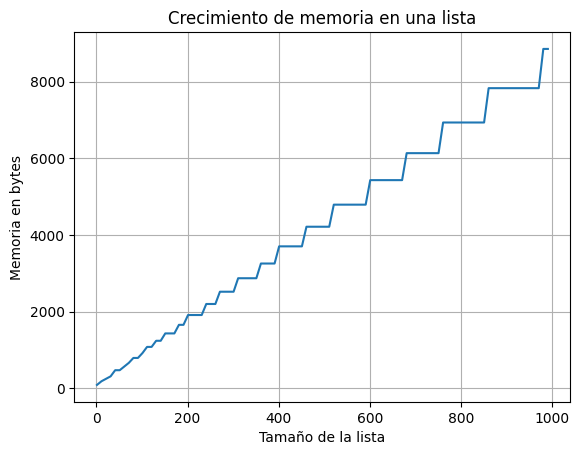

In [88]:
import matplotlib.pyplot as plt
import sys

tamaños = []
memoria = []

datos = []
for i in range(1000):
    datos.append(i)
    if i % 10 == 0:
        tamaños.append(len(datos))
        memoria.append(sys.getsizeof(datos))

plt.plot(tamaños, memoria)
plt.xlabel("Tamaño de la lista")
plt.ylabel("Memoria en bytes")
plt.title("Crecimiento de memoria en una lista")
plt.grid(True)
plt.show()

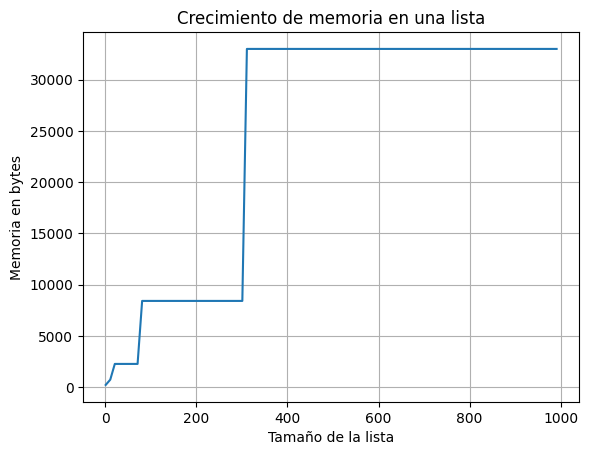

In [92]:
conjunto = set()
memoria_set = []
tamaños = []

for i in range(1000):
    conjunto.add(i)
    if i % 10 == 0:
        tamaños.append(len(conjunto))
        memoria_set.append(sys.getsizeof(conjunto))


plt.plot(tamaños, memoria_set)
plt.xlabel("Tamaño de la lista")
plt.ylabel("Memoria en bytes")
plt.title("Crecimiento de memoria en una lista")
plt.grid(True)
plt.show()

---

# 🔬 Herramientas para análisis avanzado de memoria en Python

## 📦 ¿Por qué buscar algo más que `sys.getsizeof()`?

Como ya vimos, `sys.getsizeof()`:

* 🔹 **No mide recursivamente** el contenido interno de las estructuras.
* 🔹 Solo da el tamaño **en ese instante**.
* 🔹 No permite observar **cómo cambia el consumo línea por línea** durante la ejecución.

Para resolver esas limitaciones, existen herramientas como:

---

## 🧰 1. `memory_profiler`

📌 **¿Qué es?**
Una herramienta que te permite ver **cuánto consume de memoria cada línea de tu código Python**.

📦 Ideal para:

* Detectar qué líneas gastan más memoria.
* Evaluar el impacto de crear estructuras grandes.
* Diagnosticar funciones que crecen sin control.

🔧 **Instalación:**

```bash
pip install memory_profiler
```

---

### 🧪 Ejemplo básico:

```python
from memory_profiler import profile

@profile
def construir_lista():
    datos = []
    for i in range(10000):
        datos.append(i)
    return datos

construir_lista()
```

🧠 Al ejecutar el script con:

```bash
python -m memory_profiler tu_script.py
```

Obtendrás una salida tipo:

```
Line #    Mem usage    Increment   Line Contents
================================================
     4     10.5 MiB     10.5 MiB   @profile
     5     10.5 MiB      0.0 MiB   def construir_lista():
     6     10.5 MiB      0.0 MiB       datos = []
     7     12.3 MiB      1.8 MiB       for i in range(10000):
     8     12.3 MiB      0.0 MiB           datos.append(i)
```

📊 Esto te muestra **cuánta memoria crece entre líneas**, ideal para depurar o entender estructuras complejas.

---

## 🔎 2. `tracemalloc`

📌 **¿Qué es?**
Una herramienta incorporada en Python (desde 3.4) que permite:

* **Rastrear asignaciones de memoria** durante la ejecución.
* Ver **dónde en el código** se asignó memoria.
* Identificar fugas de memoria o acumulaciones inesperadas.

📦 Ideal para:

* Analizar proyectos grandes
* Rastrear asignaciones línea a línea o por archivo
* Medir el crecimiento total de memoria

---

### 🧪 Ejemplo básico:

```python
import tracemalloc

tracemalloc.start()

# Código que quieres medir
lista = [i for i in range(100000)]

snapshot = tracemalloc.take_snapshot()
top_stats = snapshot.statistics("lineno")

print("Top 5 líneas que más memoria usaron:")
for stat in top_stats[:5]:
    print(stat)
```

Salida esperada:

```
Top 5 líneas que más memoria usaron:
tu_script.py:4: size=781 KiB, count=100000, average=8 B
...
```

🔍 Aquí puedes ver cuántos objetos fueron creados, cuánto espacio ocupan, y en qué línea sucedió.

---

## 📌 Comparación rápida

| Herramienta       | Ventaja                | Ideal para                              |
| ----------------- | ---------------------- | --------------------------------------- |
| `sys.getsizeof()` | Simplicidad            | Medidas básicas y estructuras simples   |
| `memory_profiler` | Medición por línea     | Evaluar funciones en detalle            |
| `tracemalloc`     | Rastro de asignaciones | Diagnóstico profundo y fugas de memoria |

---

## 🧠 Recomendaciones

* Si estás aprendiendo: empieza con `sys.getsizeof()` y usa `print()` o trazas.
* Si estás investigando cuellos de botella: prueba `memory_profiler`.
* Si estás trabajando en un proyecto grande o en producción: explora `tracemalloc`.

---


In [94]:
%pip install memory_profiler

In [97]:
#ejecutar en editor
from memory_profiler import profile

@profile
def construir_lista():
    datos = []
    for i in range(10000):
        datos.append(i)
    return datos

datos = construir_lista()

ERROR: Could not find file /tmp/ipython-input-97-3001326322.py


In [99]:
import tracemalloc

tracemalloc.start()

# Código que quieres medir
lista = [i for i in range(100000)]

snapshot = tracemalloc.take_snapshot()
top_stats = snapshot.statistics("lineno")

print("Top 5 líneas que más memoria usaron:")
for stat in top_stats[:15]:
    print(stat)

Top 5 líneas que más memoria usaron:
/tmp/ipython-input-99-3442680221.py:6: size=3899 KiB, count=99744, average=40 B
/tmp/ipython-input-98-3302303802.py:6: size=3899 KiB, count=99744, average=40 B
/usr/lib/python3.11/inspect.py:2203: size=203 KiB, count=2, average=101 KiB
<frozen abc>:123: size=57.7 KiB, count=672, average=88 B
/usr/local/lib/python3.11/dist-packages/IPython/core/compilerop.py:101: size=12.1 KiB, count=137, average=91 B
/usr/local/lib/python3.11/dist-packages/google/colab/_variable_inspector.py:28: size=6512 B, count=1, average=6512 B
/usr/lib/python3.11/inspect.py:2224: size=4280 B, count=13, average=329 B
/usr/local/lib/python3.11/dist-packages/zmq/sugar/attrsettr.py:44: size=3245 B, count=59, average=55 B
/usr/lib/python3.11/json/decoder.py:353: size=1931 B, count=25, average=77 B
/usr/local/lib/python3.11/dist-packages/traitlets/traitlets.py:744: size=1862 B, count=26, average=72 B
/usr/local/lib/python3.11/dist-packages/traitlets/traitlets.py:1535: size=1603 B, co